In [1]:
import os
import torch
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import softmax
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

from lib.data.utils import Color
from lib.data.datasets import (
    ColoredMNISTDataset,
    get_ColoredMNISTDataset_dataloader
)
from lib.models import (
    CVAEFilm, BetaVAEForEmbedding
)
from lib.plotting.fonts import montserrat_regular, montserrat_medium, montserrat_bold
from lib.plotting import fig_to_rgba
from lib.analysis import tg_mds
from lib.memory_buffers.utils import (
    generate_vector_by_similarity, 
    generate_vector_by_angle,
    l2normalize
)


device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
color_codes = [Color.RED, Color.GREEN, Color.CYAN, Color.YELLOW, Color.MAGENTA]
test_dataset = ColoredMNISTDataset(color_codes=color_codes, resize=32, train=False)
test_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=64,
    dataset=test_dataset,
    drop_last=False, shuffle=False
)

##### Setup Beta-VAE (Capacity Constrained)

In [3]:
path = "resources/beta_vae_capacity.pt"
ckpts = torch.load(path, weights_only=False)

def load_model(ckpt):
    model = BetaVAEForEmbedding(ckpt["config"])
    model.load_state_dict(ckpt["state_dict"])
    model.to(device)
    model.eval()
    return model

@torch.no_grad()
def get_reconstruction(model, x):
    model.eval()
    x = torch.tensor(x, device=device)
    mu, logvar = model.encode(x)
    z = model._reparameterize(mu, logvar)
    rec = model.decode(z)
    return rec.cpu().numpy()

##### Setup Conditional-VAE FiLM

In [4]:
path = "resources/ckpt_cvae_film_basic.pt"
ckpt = torch.load(path, weights_only=False)
cvae = CVAEFilm(
    config=ckpt["config"],
    **ckpt["kwargs"]
) 
cvae.load_state_dict(ckpt["state_dict"])
cvae.to(device)
cvae.eval()

@torch.no_grad()
def get_embedding(cvae, batch):
    batch.to(device)
    sem_embed = cvae.sem_embeddings(batch.label_ids)
    feat_embed = cvae.feat_embeddings(batch.feature_ids)
    mu, _ = cvae.encode(batch.pixel_values)
    embed = torch.cat([mu.flatten(1), sem_embed, feat_embed], dim=-1)
    return embed.cpu().numpy()

##### Experiment Setup

In [5]:
X = []
labels = []
features = []
for batch in test_dataloader:
    labels.append(batch.label_ids.numpy())
    features.append(batch.feature_ids.numpy())
    h = get_embedding(cvae, batch)
    X.append(h)
X = np.vstack(X)
labels = np.hstack(labels)
features = np.hstack(features)

def sample_trial(n):
    pos = np.random.randint(0,X.shape[0], (n,))
    return X[pos], labels[pos], features[pos]

def generate_temporal_embeddings(gammas, dim, t0=None):
    Ts = []

    if t0 is not None:
        t = t0
    else:
        t = l2normalize(np.random.randn(dim))
    Ts.append(t)
    for i in range(len(gammas)):
        t = generate_vector_by_angle(t, gammas[i])
        Ts.append(t)

    return np.stack(Ts[1:])

# Recency

In [6]:
def log_compression(qk_score, t_keys, T, beta=1, kappa=0.05, tau0=0.5, eps=1e-6):
    # 1) log-time bias (uniform over log age): b_i = -log(Delta_i)
    Delta = np.clip(T - t_keys, min=eps)
    b = -np.log(Delta)
    # 2) query-time temperature tau(T) = tau0 + kappa*T
    tau = tau0 + kappa * T
    # 3) compute log-compressed corrected qk-match scores
    logits = qk_score/tau + beta*b
    return logits

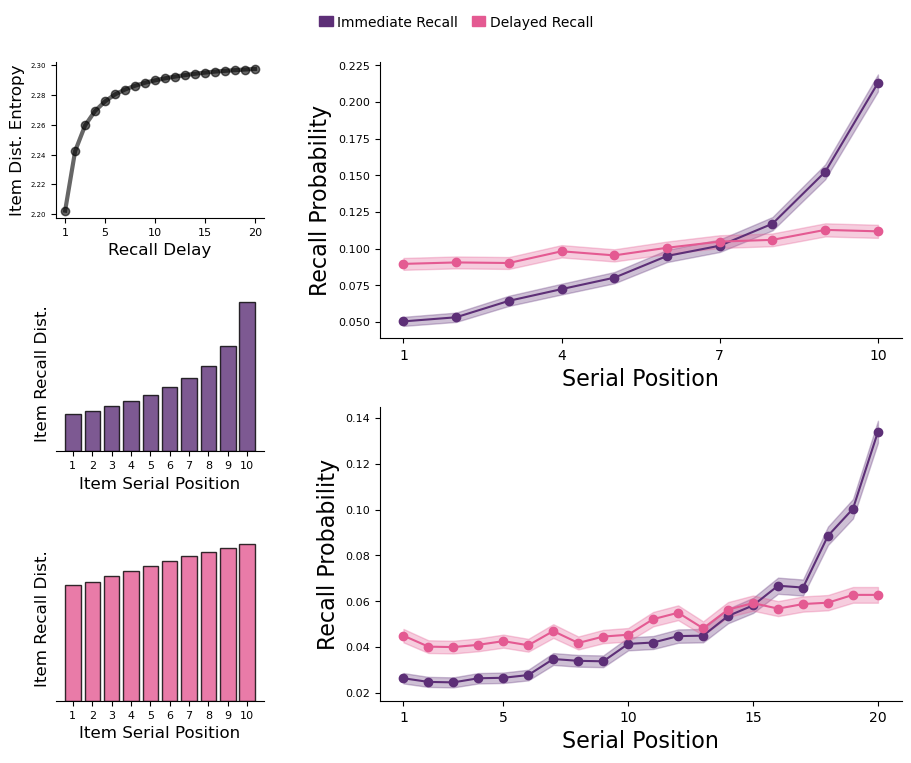

In [16]:
fig = plt.figure(figsize=(9,7), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=6, ncols=4,
    width_ratios=[1,1,2.5,2.5],
    wspace=0.2
)

leg_labels = ["Immediate Recall", "Delayed Recall"]
leg_colors = ["#5D2F77", "#E45A92"]
palette = {k:v for k,v in zip(leg_labels, leg_colors)}


### VISUALS [(1,2), 0] ###

# Setup
n_items = 10
T = 20

gammas = np.linspace(0.1, 0.9, n_items)[::-1]
temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])
natural_time_embeddings = generate_temporal_embeddings(np.repeat(0.1, T), X.shape[-1], temporal_embeddings[-1])

# Generate Data
item_embeddings, label_ids, feature_ids = sample_trial(n_items)
item_embeddings = l2normalize(item_embeddings, dim=-1)

keys = np.hstack([temporal_embeddings, item_embeddings])

recall_lags = [1, T]

probs = []
for i, recall_lag in enumerate(np.array(recall_lags)-1):
    ax = fig.add_subplot(gs[(2+2*i):(2+2*i + 2),:2])

    t_recall = n_items + recall_lag

    query = natural_time_embeddings[recall_lag]
    query = np.hstack([query, np.zeros(keys.shape[-1] - query.shape[-1])])

    s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
    s = log_compression(s, np.arange(keys.shape[0]), t_recall)
    ps = softmax(0.5*s)
    probs.append(ps)

    ax.bar(range(len(s)), ps, color=leg_colors[i], edgecolor="black", alpha=0.8)

    ax.set_xticks(
        ticks=np.arange(n_items), 
        labels=np.arange(n_items) + 1,
        fontsize=8
    )
    ax.set_xlabel("Item Serial Position", fontsize=12)
    ax.set_ylabel("Item Recall Dist.", fontsize=12)
    ax.set_yticks([])

    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)


### VISUALS [0,0] ###
ax = fig.add_subplot(gs[:2,:2])

recall_lags = np.arange(T)+1
h = []
for i, recall_lag in enumerate(np.array(recall_lags)-1):
    t_recall = n_items + recall_lag

    query = natural_time_embeddings[recall_lag]
    query = np.hstack([query, np.zeros(keys.shape[-1] - query.shape[-1])])

    s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
    s = log_compression(s, np.arange(keys.shape[0]), t_recall)
    ps = softmax(0.5*s)
    h.append(-np.sum(ps*np.log(ps)))

ax.plot(recall_lags, h, "o-", linewidth=3, markersize=6, alpha=0.6, color="black")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks(
    ticks=[1,5,10,15,20], 
    labels=[1,5,10,15,20],
    fontsize=8
)
ax.tick_params(axis="y", labelsize=5)
ax.set_ylabel("Item Dist. Entropy", fontsize=12)
ax.set_xlabel("Recall Delay", fontsize=12)


### VISUALS [0,1] ###
ax = fig.add_subplot(gs[:3,2:])

# Setup
n_items = 10
T = 20

gammas = np.linspace(0.1, 0.9, n_items)[::-1]
temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])
natural_time_embeddings = generate_temporal_embeddings(np.repeat(0.1, T), X.shape[-1], temporal_embeddings[-1])

# Generate Data
item_embeddings, label_ids, feature_ids = sample_trial(n_items)
item_embeddings = l2normalize(item_embeddings, dim=-1)

keys = np.hstack([temporal_embeddings, item_embeddings])

recall_lags = [1, T]

probs = []
for i, recall_lag in enumerate(np.array(recall_lags)-1):
    t_recall = n_items + recall_lag

    query = natural_time_embeddings[recall_lag]
    query = np.hstack([query, np.zeros(keys.shape[-1] - query.shape[-1])])

    s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
    s = log_compression(s, np.arange(keys.shape[0]), t_recall)
    ps = softmax(0.5*s)
    probs.append(ps)

sim = 5000
for i in range(len(probs)):
    d = np.random.choice(n_items, size=sim, p=probs[i])
    d = pd.Series(d).value_counts().reset_index().sort_values("index")
    t = d["index"].values
    mean = d["count"].values/sim
    se = np.sqrt(mean*(1-mean)/sim)
    ax.plot(t, mean, "o-", label=leg_labels[i], color=leg_colors[i])
    ax.fill_between(t, mean-se, mean+se, alpha=0.3, color=leg_colors[i])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.set_xticks(ticks=[0,3,6,9], labels=[1,4,7,10], fontsize=10)
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("Serial Position", fontsize=16)
ax.set_ylabel("Recall Probability", fontsize=16)


### VISUALS [1,1] ###
ax = fig.add_subplot(gs[3:,2:])

# Setup
n_items = 20
T = 20

gammas = np.linspace(0.1, 0.9, n_items)[::-1]
temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])
natural_time_embeddings = generate_temporal_embeddings(np.repeat(0.1, T), X.shape[-1], temporal_embeddings[-1])

# Generate Data
item_embeddings, label_ids, feature_ids = sample_trial(n_items)
item_embeddings = l2normalize(item_embeddings, dim=-1)

keys = np.hstack([temporal_embeddings, item_embeddings])

recall_lags = [1, T]

probs = []
for i, recall_lag in enumerate(np.array(recall_lags)-1):
    t_recall = n_items + recall_lag

    query = natural_time_embeddings[recall_lag]
    query = np.hstack([query, np.zeros(keys.shape[-1] - query.shape[-1])])

    s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
    s = log_compression(s, np.arange(keys.shape[0]), t_recall)
    ps = softmax(0.5*s)
    probs.append(ps)

sim = 5000
for i in range(len(probs)):
    d = np.random.choice(n_items, size=sim, p=probs[i])
    d = pd.Series(d).value_counts().reset_index().sort_values("index")
    t = d["index"].values
    mean = d["count"].values/sim
    se = np.sqrt(mean*(1-mean)/sim)
    ax.plot(t, mean, "o-", label=leg_labels[i], color=leg_colors[i])
    ax.fill_between(t, mean-se, mean+se, alpha=0.3, color=leg_colors[i])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.set_xticks(ticks=[0,4,9,14,19], labels=[1,5,10,15,20], fontsize=10)
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("Serial Position", fontsize=16)
ax.set_ylabel("Recall Probability", fontsize=16)

leg = fig.legend(
    handles=[Patch(color=v, label=k) for k,v in palette.items()],
    loc="center",
    ncol=3,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=1.0,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05)
)

In [17]:
fig.savefig("visuals/list-free_recall.pdf")

# Temporal Embedding

In [18]:
gammas = 0.8*np.linspace(0.1, 0.9, 10)[::-1]

In [19]:
def get_rotation_matrix(theta):
    return np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta), np.cos(theta)]
    ])

Xs = []
Xs.append(np.array([0,1]))
for i, theta in enumerate(gammas):
    m = get_rotation_matrix(theta)
    x = m @ Xs[i] 
    Xs.append(x)

Xs = np.vstack(Xs)[:-1]

Text(0.5, 0, 'Temporal Embeddings')

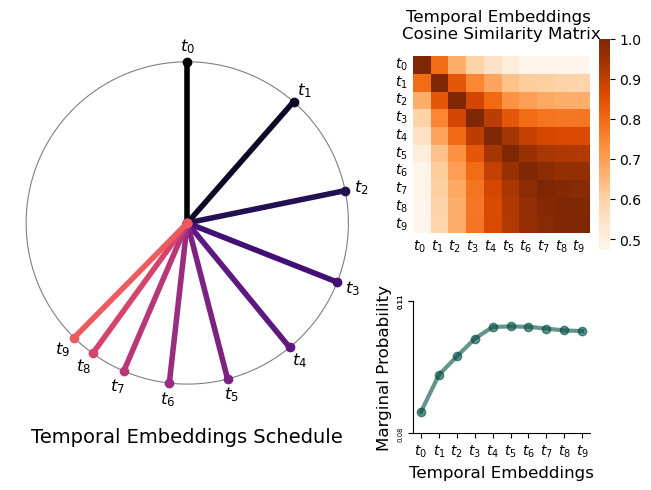

In [24]:
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[2,1],
    height_ratios=[2,1]
)

### VISUAL [:,0] ###
ax = fig.add_subplot(gs[:,0])

colormap = plt.cm.magma
color_prop = np.linspace(0., 0.65, Xs.shape[0])
for i, v in enumerate(Xs):
    c = colormap(color_prop[i])
    ax.plot([0, v[0]], [0, v[1]], "o-", linewidth=4, markersize=6, color=c)
    ax.text(
        v[0] * 1.1, v[1] * 1.1,
        fr"$t_{i}$", fontsize=12,
        ha='center', va='center'
    )
ax.set_aspect('equal', adjustable='box')

th = np.linspace(0, 2*np.pi, 600)
xc, yc = np.cos(th), np.sin(th)
ax.plot(xc, yc, linewidth=0.8, color="grey", zorder=-1)

pad = 0.1
ax.set_xlim(-1 - pad, 1 + pad)
ax.set_ylim(-1 - pad, 1 + pad)
ax.axis("off")

ax.text(
    0.5, -0.12,
    "Temporal Embeddings Schedule", fontsize=14,
    ha='center',
    transform=ax.transAxes
)


### VISUAL [0,1] ###
ax = fig.add_subplot(gs[0,1])

Ts = []

t = l2normalize(np.random.randn(512))
Ts.append(t)
for i in range(len(gammas)):
    t = generate_vector_by_angle(t, gammas[i])
    Ts.append(t)
temporal_embeddings = np.stack(Ts[1:])

rho = 1 - pairwise_distances(temporal_embeddings, metric="cosine")

sns.heatmap(
    rho, 
    cmap="Oranges",
    cbar=True, square=True,
    annot=False,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_xticks(np.arange(Xs.shape[0]), [fr"$t_{i}$" for i in np.arange(Xs.shape[0])], ha="left")
ax.set_yticks(np.arange(Xs.shape[0]), [fr"$t_{i}$" for i in np.arange(Xs.shape[0])], va="top", rotation=0)
ax.tick_params(length=0)
ax.set_title("Temporal Embeddings \nCosine Similarity Matrix", fontsize=12, y=1.05)


### VISUAL [1,1] ###
ax = fig.add_subplot(gs[1,1])

x = softmax(rho, axis=-1).mean(axis=0)
ax.plot(x, marker="o", linewidth=3, markersize=6, color="#004d42", alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks(np.arange(Xs.shape[0]), [fr"$t_{i}$" for i in np.arange(Xs.shape[0])])
ax.set_yticks(ticks=ax.get_yticks()[[0, 3, -1]], labels=ax.get_yticks()[[0, 3, -1]], fontsize=5, rotation="vertical", va="center")
ax.set_ylabel("Marginal Probability", fontsize=12)
ax.set_xlabel("Temporal Embeddings", fontsize=12)

In [25]:
fig.savefig("visuals/temporal_embeddings.pdf")

# Forward Effect

In [26]:
n_items = 10
gammas = np.linspace(0.1, 0.9, n_items)[::-1]

""" b = 0.3/(n_items/10)
gammas = 0.9*np.exp(-b*np.arange(n_items))
gammas = np.clip(gammas, min=0.1) """

temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])
item_embeddings, label_ids, feature_ids = sample_trial(n_items)
item_embeddings = l2normalize(item_embeddings, dim=-1)

In [54]:
sim = 5000
data = []

np.random.seed(51) # 51

for n_items in [10, 20]:

    gammas = np.linspace(0.1, 0.9, n_items)[::-1]
    temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])
    item_embeddings, label_ids, feature_ids = sample_trial(n_items)
    item_embeddings = l2normalize(item_embeddings, dim=-1)

    for w in [0., 0.5, 1]:

        temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])
        item_embeddings, label_ids, feature_ids = sample_trial(n_items)
        item_embeddings = l2normalize(item_embeddings, dim=-1)

        for _ in range(sim):
            seed = np.random.permutation(np.arange(1,n_items-1))[0]

            query = np.hstack([temporal_embeddings, item_embeddings])[seed]
            keys = np.hstack([w*temporal_embeddings, (1-w)*item_embeddings])

            s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
            s[seed] = -np.inf
            p = softmax(10*s)
            
            choice = np.random.choice(n_items, p=p)

            data.append(dict(
                w=w,
                n_items=n_items,
                seed=seed,
                choice=choice,
                lag=choice-seed
            ))

data = pd.DataFrame(data)

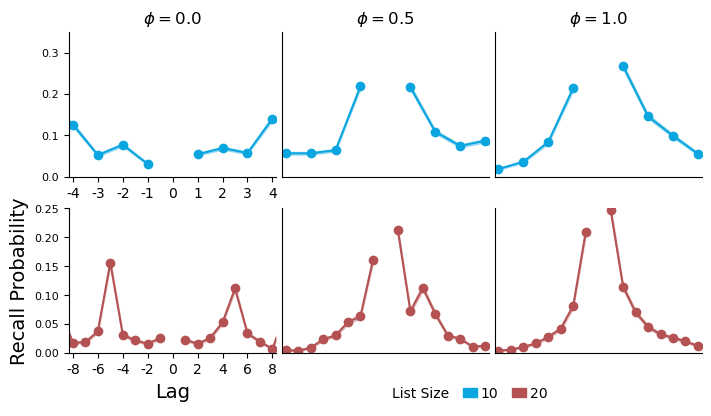

In [55]:
fig, axes = plt.subplots(data.n_items.nunique(), data.w.nunique(), figsize=(7,4))

leg_labels = ["10", "20"]
leg_colors = ["#0BA6DF", "#B45253"]

for j, n_items in enumerate(data.n_items.unique()):
    for i, w in enumerate(data.w.unique()):
        ax = axes[j,i]
        d = data.query(f"w=={w} and n_items=={n_items}")

        x = np.array(d.lag.value_counts().index)
        y = d.lag.value_counts().values/sim
        pos = np.argsort(x)
        x = x[pos]
        y = y[pos]

        ax.plot(x[x<0], y[x<0], "o-", color=leg_colors[j])
        se = np.sqrt(y[x<0]*(1-y[x<0])/sim)
        ax.fill_between(x[x<0], y[x<0]-se, y[x<0]+se, alpha=0.3, color=leg_colors[j])

        ax.plot(x[x>0], y[x>0], "o-", color=leg_colors[j])
        se = np.sqrt(y[x>0]*(1-y[x>0])/sim)
        ax.fill_between(x[x>0], y[x>0]-se, y[x>0]+se, alpha=0.3, color=leg_colors[j])

        if j==0:
            ax.set_xlim(-4.15,4.15)
            ax.set_xticks(np.arange(-4,5), np.arange(-4,5))
            ax.set_ylim(0, 0.35)
        else:
            ax.set_xlim(-8.3,8.3)
            ax.set_xticks(np.arange(-8,10,2), np.arange(-8,10,2))
            ax.set_ylim(0, 0.25)
    
            if i==0:
                ax.set_xlabel("Lag", fontsize=14)
                ax.set_ylabel("Recall Probability", fontsize=14)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if i > 0:
            ax.set_xticks([])
            ax.set_yticks([])

        if j==0:
            ax.set_title(r"$\phi=$" + f"{w}")

        ax.tick_params(axis="y", labelsize=8)

fig.legend(
    handles=[Patch(color="none", label="List Size")] + [Patch(color=v, label=k) for k,v in zip(leg_labels, leg_colors)],
    loc="center",
    ncol=3,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=1.0,
    frameon=False,
    bbox_to_anchor=(0.65, 0.03)
)

plt.tight_layout(pad=0.3)

# Paths

In [205]:
np.random.seed(91) # 49, 73, 83

In [206]:
n_items = 10
colormap = plt.cm.magma
color_prop = np.linspace(0., 0.65, n_items)

gammas = np.linspace(0.5, 0.9, n_items)[::-1]
temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])

item_embeddings, label_ids, feature_ids = sample_trial(n_items)
item_embeddings = l2normalize(item_embeddings, dim=-1)

rho_t = pairwise_distances(temporal_embeddings, metric="cosine")
rho_s = pairwise_distances(item_embeddings, metric="cosine")

###

sim = 100
ws = [0.25, 0.5, 0.75, 1]

images = []
all_paths = []
for i, w in enumerate(ws):
    keys = np.hstack([w*temporal_embeddings, (1-w)*item_embeddings])

    def f():
        c = [0]
        h = np.array([1] +  [-1 for _ in range(n_items-1)])
        for i in range(1,n_items):
            query = keys[i-1]
            s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
            s = s + (h > 0) * -9999
            p = softmax(10*s)
            choice = np.random.choice(n_items, p=p)
            h[choice] = 1
            c.append(choice)
        return np.array(c)
    
    paths = np.array([f() for _ in range(sim)])
    all_paths.append(paths)

    top = 5
    v = pd.DataFrame([str(i) for i in paths]).value_counts()
    x = v.index
    y = v.values
    x = [np.fromstring(i[0].strip("[]"), sep=" ").astype(int) for i in x][:top]
    y = y[:top]

    ### VISUALS ###
    fig = plt.figure(figsize=(4,4.5), constrained_layout=True)
    gs = fig.add_gridspec(
        nrows=2, ncols=1,
        height_ratios=[3,1]
    )
 
    coord = tg_mds(rho_t, 2)
    ax = fig.add_subplot(gs[0])
    for i in range(len(x)):
        coord_ = coord[x[i]]
        y_linewidth = (len(x) - i)*2 
        ax.plot(coord_[:,0], coord_[:,1], "-", color="black", linewidth=y_linewidth, alpha=0.2)
    for i in range(n_items):
        ax.plot(coord[i,0], coord[i,1], "o", color=colormap(color_prop[i]), markersize=20)
        ax.text(coord[i,0], coord[i,1], f"{i}", color="white", ha="center", va="center")
    ax.axis("off")

    ax = fig.add_subplot(gs[1])
    ax.plot([0,9], [1,1], "-", linewidth=2, color="black", alpha=0.8)
    for i in range(n_items):
        ax.plot(i, 1, "o", color=colormap(color_prop[x[0][i]]), markersize=20)
        ax.text(i, 1, f"{x[0][i]}", color="white", ha="center", va="center")
    ax.axis("off")

    images.append(fig_to_rgba(fig, dpi=500))
    plt.close(fig)

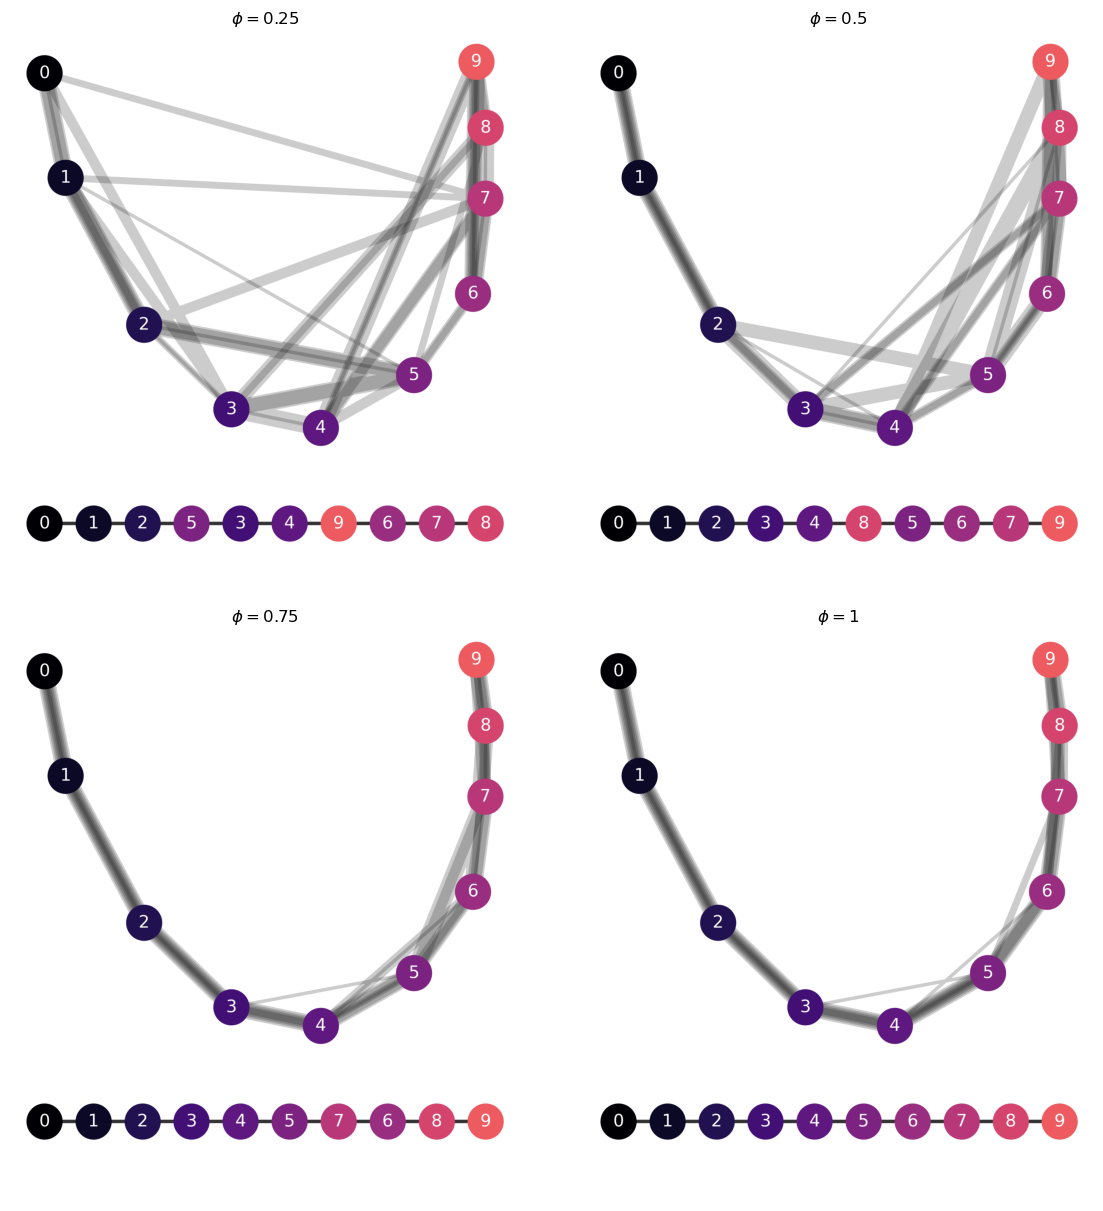

In [207]:
fig, axes = plt.subplots(2,2, figsize=(12,12))
axes = axes.flatten()

for i, image in enumerate(images):
    ax = axes[i]
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(r"$\phi=$" + f"{ws[i]}")
plt.tight_layout(pad=0.3)

In [ ]:
np.random.seed(91)

n_items = 10
colormap = plt.cm.magma
color_prop = np.linspace(0., 0.65, n_items)

gammas = np.linspace(0.5, 0.9, n_items)[::-1]
temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])

item_embeddings, label_ids, feature_ids = sample_trial(n_items)
item_embeddings = l2normalize(item_embeddings, dim=-1)

rho_t = pairwise_distances(temporal_embeddings, metric="cosine")
rho_s = pairwise_distances(item_embeddings, metric="cosine")

###

sim = 100
ws = [0.25, 0.5, 0.75, 1]

images = []
all_paths = []
for i, w in enumerate(ws):
    keys = np.hstack([w*temporal_embeddings, (1-w)*item_embeddings])

    def f():
        c = [0]
        h = np.array([1] +  [-1 for _ in range(n_items-1)])
        for i in range(1,n_items):
            query = keys[i-1]
            s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
            s = s + (h > 0) * -9999
            p = softmax(10*s)
            choice = np.random.choice(n_items, p=p)
            h[choice] = 1
            c.append(choice)
        return np.array(c)
    
    paths = np.array([f() for _ in range(sim)])
    all_paths.append(paths)

    top = 5
    v = pd.DataFrame([str(i) for i in paths]).value_counts()
    x = v.index
    y = v.values
    x = [np.fromstring(i[0].strip("[]"), sep=" ").astype(int) for i in x][:top]
    y = y[:top]

    ### VISUALS ###
    fig = plt.figure(figsize=(4,4.5), constrained_layout=True)
    gs = fig.add_gridspec(
        nrows=2, ncols=1,
        height_ratios=[3,1]
    )
 
    coord = tg_mds(rho_t, 2)
    ax = fig.add_subplot(gs[0])
    for i in range(len(x)):
        coord_ = coord[x[i]]
        y_linewidth = (len(x) - i)*2 
        ax.plot(coord_[:,0], coord_[:,1], "-", color="black", linewidth=y_linewidth, alpha=0.2)
    for i in range(n_items):
        ax.plot(coord[i,0], coord[i,1], "o", color=colormap(color_prop[i]), markersize=20)
        ax.text(coord[i,0], coord[i,1], f"{i}", color="white", ha="center", va="center")
    ax.axis("off")

    ax = fig.add_subplot(gs[1])
    ax.plot([0,9], [1,1], "-", linewidth=2, color="black", alpha=0.8)
    for i in range(n_items):
        ax.plot(i, 1, "o", color=colormap(color_prop[x[0][i]]), markersize=20)
        ax.text(i, 1, f"{x[0][i]}", color="white", ha="center", va="center")
    ax.axis("off")

    fig.savefig(f"visuals/paths_{w}.pdf")

In [217]:
np.random.seed(44)

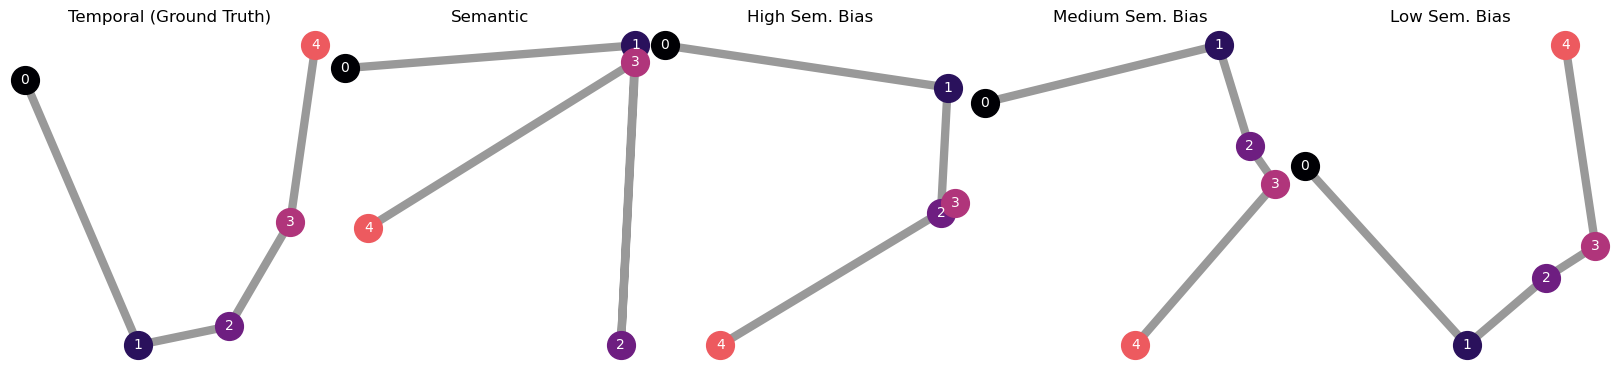

In [218]:
n_items = 5

gammas = np.linspace(0.5, 0.9, n_items)[::-1]
temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])

item_embeddings, label_ids, feature_ids = sample_trial(n_items)
item_embeddings = l2normalize(item_embeddings, dim=-1)

rho_t = pairwise_distances(temporal_embeddings, metric="cosine")
rho_s = pairwise_distances(item_embeddings, metric="cosine")

fig, axes = plt.subplots(1,5, figsize=(16,3.5))
axes = axes.flatten()
colormap = plt.cm.magma
color_prop = np.linspace(0., 0.65, n_items)

ax = axes[0]
coord = tg_mds(rho_t, 2)
ax.plot(coord[:,0], coord[:,1], "-", color="black", linewidth=6, alpha=0.4)
for i in range(n_items):
    ax.plot(coord[i,0], coord[i,1], "o", color=colormap(color_prop[i]), markersize=20)
    ax.text(coord[i,0], coord[i,1], f"{i}", color="white", ha="center", va="center")

ax = axes[1]
coord = tg_mds(rho_s, 2)
ax.plot(coord[:,0], coord[:,1], "-", color="black", linewidth=6, alpha=0.4)
for i in range(n_items):
    ax.plot(coord[i,0], coord[i,1], "o", color=colormap(color_prop[i]), markersize=20)
    ax.text(coord[i,0], coord[i,1], f"{i}", color="white", ha="center", va="center")


ws = [0.4, 0.55, 0.65]
for i, w in enumerate(ws):
    keys = np.hstack([w*temporal_embeddings, (1-w)*item_embeddings])
    rho_k = pairwise_distances(keys, metric="cosine")

    ax = axes[i+2]
    coord = tg_mds(rho_k, 2)
    ax.plot(coord[:,0], coord[:,1], "-", color="black", linewidth=6, alpha=0.4)
    for i in range(n_items):
        ax.plot(coord[i,0], coord[i,1], "o", color=colormap(color_prop[i]), markersize=20)
        ax.text(coord[i,0], coord[i,1], f"{i}", color="white", ha="center", va="center")

titles = ["Temporal (Ground Truth)", "Semantic"] + ["High Sem. Bias", "Medium Sem. Bias", "Low Sem. Bias"] # ["Temp-Sem Path " + fr"$\phi={w}$" for w in ws]
for i, ax in enumerate(axes):
    ax.axis("off")
    ax.set_title(titles[i])
    
plt.tight_layout(pad=0.)

In [219]:
n_items = 10
gammas = np.linspace(0.5, 0.9, n_items)[::-1]

def longest_consecutive_run(x):
    longest = 1
    current = 1
    for i in range(len(x)-1):
        if x[i+1] == x[i] + 1:
            current += 1
            longest = max(longest, current)
        else:
            current = 1
    return longest

def f(keys, beta=15):
    c = [0]
    h = np.array([1] +  [-1 for _ in range(n_items-1)])
    for i in range(1, n_items):
        query = keys[i-1]
        s = 1 - pairwise_distances(query[None], keys, metric="cosine").flatten()
        s = s + (h > 0) * -9999
        p = softmax(beta*s)
        choice = np.random.choice(n_items, p=p)
        h[choice] = 1
        c.append(choice)
    return np.array(c)

###

sim = 1000
ws = np.linspace(0.5,1,5)

all_paths = []
for i, w in enumerate(ws):

    paths = []    
    for _ in tqdm(range(sim)):
        temporal_embeddings = generate_temporal_embeddings(gammas, X.shape[-1])
        item_embeddings, label_ids, feature_ids = sample_trial(n_items)
        item_embeddings = l2normalize(item_embeddings, dim=-1)
        keys = np.hstack([w*temporal_embeddings, (1-w)*item_embeddings])
        paths.append(f(keys))

    all_paths.append(paths)

###

data = []
for i, paths in enumerate(all_paths):
    sequences = [longest_consecutive_run(i) for i in paths]
    data.append(sequences)
data = np.array(data)

100%|██████████| 1000/1000 [00:03<00:00, 283.67it/s]


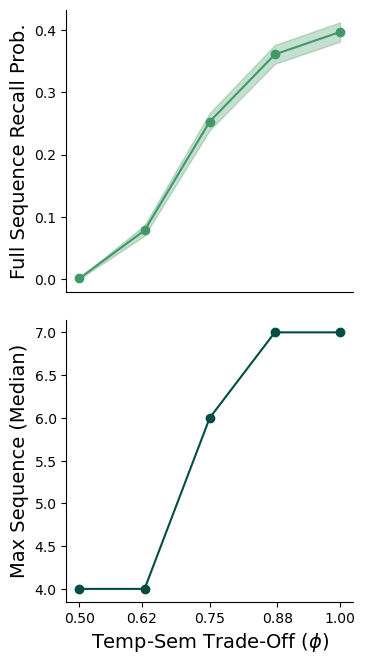

In [220]:
fig, axes = plt.subplots(2,1, figsize=(4,7))

ax = axes[0]
x = (data==10).mean(axis=-1)
se = (data==10).std(axis=-1)/np.sqrt(sim)
ax.plot(ws, x, "o-", color="#429867")
ax.fill_between(ws, x-se, x+se, alpha=0.3, color="#429867")
ax.set_xticks([])
ax.set_ylabel("Full Sequence Recall Prob.", fontsize=14)

ax = axes[1]
x = np.median(data, axis=-1)
ax.plot(ws, x, "o-", color="#004d42")
ax.set_ylabel("Max Sequence (Median)", fontsize=14)
ax.set_xlabel("Temp-Sem Trade-Off (" + r"$\phi$" + ")", fontsize=14)
ax.set_xticks(np.round(ws,2))

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(pad=2)

In [221]:
fig.savefig("visuals/free_recall-trade_off.pdf")